Setup

In [1]:
import os
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split

from sasviya.ml.linear_model import (
    LinearRegression as SASLinearRegression,
    Ridge as SASRidge,
    Lasso as SASLasso,
    ElasticNet as SASElasticNet,
)

from sasviya.ml.tree import (
    DecisionTreeRegressor as SASDecisionTreeRegressor,
    ForestRegressor as SASForestRegressor,
    GradientBoostingRegressor as SASGradientBoostingRegressor,
)

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)


from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

np.random.seed(42)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:

TRAIN_PATH = Path("train.csv")
TEST_PATH = Path("test.csv")

assert TRAIN_PATH.exists(), f"Missing file: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Missing file: {TEST_PATH}"

print("Train path:", TRAIN_PATH.resolve())
print("Test path :", TEST_PATH.resolve())


Train path: /workspaces/myfolder/train.csv
Test path : /workspaces/myfolder/test.csv


Load the Data


In [3]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())
display(test.head())


Train shape: (100000, 46)
Test shape : (15000, 45)


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,ORDER_TOTAL_CHARGES,GENDER,ZIP,STATECODE,CITY,COUNTY_NAME,X,Y,REGION,RACE_CD,PATIENT_AGE,DIAGNOSIS_GROUP,ICD9_TARGET,MS_DRG_CODE,MS_DRG_DESC,DRG_APR_CODE,DRG_APR_DESC,DRG_APR_SEVERITY,DIAGNOSIS_SUBCAT_CODE,DIAGNOSIS_SUBCAT_DESC,DIAGNOSIS_ICD_CODE,DIAGNOSIS_LONG_DESC,PROCEDURE_SUBCAT_CODE,PROCEDURE_SUBCAT_DESC,PROCEDURE_ICD_CODE,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS,ADMIT_LOS
0,300000000,574545941,256444,0,HEART,SKILLED NURSING FACIL,Y,0,2001,1,18768,F,33446,FL,Delray Beach,Palm Beach,-80.173388,26.451567,Region 11,Black,96,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,3,428,HEART FAILURE,428.23,ACUTE ON CHRONIC SYSTOLIC HEART FAILURE,89,"INTERVIEW, EVALUATION, C",89.49,AUTOMATIC IMPLANTABLE CARDIOVERTERDEFIBRILLATO...,42823,Congestive heart failure; nonhypertensive [108.],1,32,4,4,Hosp 17,4,1,4
1,300000001,700724256,319034,1,HEART,SKILLED NURSING FACIL,N,1,8003,1,16584,F,33467,FL,Lake Worth,Palm Beach,-80.177700,26.606929,Region 1,Others,85,CHF,1,291,HEART FAILURE & SHOCK W MCC,194,HEART FAILURE,3,428,HEART FAILURE,428.23,ACUTE ON CHRONIC SYSTOLIC HEART FAILURE,38,"INCISION, EXCISION, AND",38.93,VENOUS CATHETERIZATION NOT ELSEWHERE CLASSIFIED,42823,Congestive heart failure; nonhypertensive [108.],0,0,0,5,Hosp 15,1,0,7
2,300000002,758601585,262051,0,HEART,HOME HEALTH AGENCY,Y,2,497217,1,30432,M,33455,FL,Hobe Sound,Martin,-80.143309,27.075482,Region 1,White,78,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.23,ACUTE ON CHRONIC SYSTOLIC HEART FAILURE,.,NaN,.,NaN,42823,Congestive heart failure; nonhypertensive [108.],1,47,3,3,Hosp 19,2,2,4
3,300000003,660243636,226751,1,PULMONARY,HOME HEALTH AGENCY,Y,1,4002,1,21517,M,33455,FL,Hobe Sound,Martin,-80.143309,27.075482,Region 8,White,87,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.00,CONGESTIVE HEART FAILURE UNSPECIFIED,.,NaN,.,NaN,4280,Congestive heart failure; nonhypertensive [108.],0,4,0,2,Hosp 14,2,2,5
4,300000004,572184863,284130,3,HEART,SKILLED NURSING FACIL,Y,1,326852,1,14583,M,33321,FL,Fort Lauderdale,Broward,-80.266294,26.205804,Region 11,White,81,CHF,0,291,HEART FAILURE & SHOCK W MCC,194,HEART FAILURE,2,404,HYPERTENSIVE HEART AND C,404.91,HYPERTENSIVE HEART AND CHRONIC KIDNEY DISEASE ...,.,NaN,.,NaN,40491,Hypertension with complications and secondary ...,0,11,2,3,Hosp 32,12,7,4


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,ORDER_TOTAL_CHARGES,GENDER,ZIP,STATECODE,CITY,COUNTY_NAME,X,Y,REGION,RACE_CD,PATIENT_AGE,DIAGNOSIS_GROUP,ICD9_TARGET,MS_DRG_CODE,MS_DRG_DESC,DRG_APR_CODE,DRG_APR_DESC,DRG_APR_SEVERITY,DIAGNOSIS_SUBCAT_CODE,DIAGNOSIS_SUBCAT_DESC,DIAGNOSIS_ICD_CODE,DIAGNOSIS_LONG_DESC,PROCEDURE_SUBCAT_CODE,PROCEDURE_SUBCAT_DESC,PROCEDURE_ICD_CODE,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS
0,300100000,553004402,297002,4,HEART,"ROUTINE DSCHG, HOME",Y,2,360014,1,33909,F,33445,FL,Delray Beach,Palm Beach,-80.102797,26.461329,Region 5,White,68,CHF,1,291,HEART FAILURE & SHOCK W MCC,194,HEART FAILURE,3,428,HEART FAILURE,428.00,CONGESTIVE HEART FAILURE UNSPECIFIED,99,OTHER NONOPERATIVE PROCE,99.22,INJECTION OF OTHER ANTIINFECTIVE,4280,Congestive heart failure; nonhypertensive [108.],2,68,6,4,Hosp 30,1,1
1,300100001,634863900,235415,0,HEART,"ROUTINE DSCHG, HOME",Y,1,100292,1,18657,M,35147,AL,Ragland,Saint Clair,-86.205444,33.758996,Region 3,Others,85,CHF,1,291,HEART FAILURE & SHOCK W MCC,194,HEART FAILURE,4,428,HEART FAILURE,428.43,ACUTE ON CHRONIC COMBINED SYSTOLIC AND DIASTOL...,88,OTHER DIAGNOSTIC RADIOLO,88.72,DIAGNOSTIC ULTRASOUND OF HEART,42843,Congestive heart failure; nonhypertensive [108.],3,67,8,6,Hosp 26,1,1
2,300100002,657483026,235415,10,TRANSPLANT,"ROUTINE DSCHG, HOME",Y,2,6003,0,38333,M,33446,FL,Delray Beach,Palm Beach,-80.173388,26.451567,Region 11,White,68,AMI,1,249,PERC CARDIOVASC PROC W NON-DRUG-ELUTING STENT ...,139,OTHER PNEUMONIA,2,486,PNEUMONIA ORGANISM UNSP,486.00,PNEUMONIA ORGANISM UNSPECIFIED,.,NaN,.,NaN,486,Pneumonia (except that caused by TB or STD) [1...,0,41,3,4,Hosp 10,1,1
3,300100003,922049972,235415,0,HEART,SKILLED NURSING FACIL,Y,0,320013,1,5996,M,34946,FL,Fort Pierce,Saint Lucie,-80.353492,27.482596,Region 10,White,74,CHF,1,293,HEART FAILURE & SHOCK W/O CC/MCC,194,HEART FAILURE,2,428,HEART FAILURE,428.00,CONGESTIVE HEART FAILURE UNSPECIFIED,88,OTHER DIAGNOSTIC RADIOLO,88.72,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],0,17,0,3,Hosp 21,5,0
4,300100004,609359088,202927,0,HEART,"ROUTINE DSCHG, HOME",Y,4,18007,1,21206,F,33445,FL,Delray Beach,Palm Beach,-80.102797,26.461329,Region 7,White,69,CHF,1,292,HEART FAILURE & SHOCK W CC,194,HEART FAILURE,2,428,HEART FAILURE,428.00,CONGESTIVE HEART FAILURE UNSPECIFIED,.,NaN,.,NaN,4280,Congestive heart failure; nonhypertensive [108.],0,62,6,4,Hosp 36,11,9


Check for Missing Values

In [4]:
def basic_report(df: pd.DataFrame, name: str) -> None:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing values:")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0].to_frame("missing_count"))
    print("\nDuplicate rows:", df.duplicated().sum())

basic_report(train, "Train")
basic_report(test, "Test")


--- Train ---
Shape: (100000, 46)

Data types:


,dtype
ENCOUNTER_KEY,int64
PATIENT_NUMBER,int64
DOCTOR,int64
ICU_DAYS,int64
DEPARTMENT,object
DISCHARGED_TO,object
STANDARD_ORDERS_USED,object
NUM_CHRONIC_COND,int64
DISCH_NURSE_ID,int64
ORDER_SET_USED,int64



Missing values:


,missing_count
PROCEDURE_SUBCAT_DESC,32072
PROCEDURE_LONG_DESC,32072



Duplicate rows: 0
--- Test ---
Shape: (15000, 45)

Data types:


,dtype
ENCOUNTER_KEY,int64
PATIENT_NUMBER,int64
DOCTOR,int64
ICU_DAYS,int64
DEPARTMENT,object
DISCHARGED_TO,object
STANDARD_ORDERS_USED,object
NUM_CHRONIC_COND,int64
DISCH_NURSE_ID,int64
ORDER_SET_USED,int64



Missing values:


,missing_count
PROCEDURE_SUBCAT_DESC,4778
PROCEDURE_LONG_DESC,4778



Duplicate rows: 0


In [5]:
def invalid_value_checks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Perform basic data quality checks on numeric variables.
    Returns a summary table containing the number and percentage
    of invalid observations.
    """

    checks = []

    numeric_cols = [
        "PATIENT_AGE",
        "ICU_DAYS",
        "OPERATION_COUNT",
        "NUM_CHRONIC_COND",
        "NUM_VISITS",
        "ORDER_TOTAL_CHARGES",
        "ADMIT_LOS",
    ]

    temp = df.copy()

    for col in numeric_cols:
        if col in temp.columns:
            temp[col] = pd.to_numeric(temp[col], errors="coerce")

    def add_check(description, condition):
        invalid_count = int(condition.sum())
        invalid_pct = round((invalid_count / len(temp)) * 100, 2)

        checks.append({
            "Check": description,
            "Invalid Count": invalid_count,
            "Invalid (%)": invalid_pct,
            "Status": "PASS ✅" if invalid_count == 0 else "REVIEW ⚠️"
        })

    # ----------------------------
    # Age
    # ----------------------------
    if "PATIENT_AGE" in temp.columns:
        add_check("PATIENT_AGE < 0", temp["PATIENT_AGE"] < 0)

    # ----------------------------
    # ICU
    # ----------------------------
    if "ICU_DAYS" in temp.columns:
        add_check("ICU_DAYS < 0", temp["ICU_DAYS"] < 0)

    # ----------------------------
    # Operation Count
    # ----------------------------
    if "OPERATION_COUNT" in temp.columns:
        add_check("OPERATION_COUNT < 0", temp["OPERATION_COUNT"] < 0)

    # ----------------------------
    # Chronic Conditions
    # ----------------------------
    if "NUM_CHRONIC_COND" in temp.columns:
        add_check("NUM_CHRONIC_COND < 0", temp["NUM_CHRONIC_COND"] < 0)

    # ----------------------------
    # Length of Stay
    # ----------------------------
    if "ADMIT_LOS" in temp.columns:
        add_check("ADMIT_LOS < 0", temp["ADMIT_LOS"] < 0)

    # ----------------------------
    # Logical Check
    # ----------------------------
    if {"ICU_DAYS", "ADMIT_LOS"}.issubset(temp.columns):
        add_check(
            "ICU_DAYS > ADMIT_LOS",
            temp["ICU_DAYS"] > temp["ADMIT_LOS"]
        )
    
    # ----------------------------
    # Number of Visits
    # ----------------------------
    if "NUM_VISITS" in temp.columns:
        add_check("NUM_VISITS < 0", temp["NUM_VISITS"] < 0)

    return pd.DataFrame(checks)

results = invalid_value_checks(train)

display(results)

print(f"\nTotal checks performed: {len(results)}")
print(f"Checks passed: {(results['Status'] == 'PASS ✅').sum()}")
print(f"Checks requiring review: {(results['Status'] == 'REVIEW ⚠️').sum()}")

,Check,Invalid Count,Invalid (%),Status
0,PATIENT_AGE < 0,0,0.00,PASS ✅
1,ICU_DAYS < 0,0,0.00,PASS ✅
2,OPERATION_COUNT < 0,0,0.00,PASS ✅
3,NUM_CHRONIC_COND < 0,0,0.00,PASS ✅
4,ADMIT_LOS < 0,0,0.00,PASS ✅
5,ICU_DAYS > ADMIT_LOS,10665,10.66,REVIEW ⚠️
6,NUM_VISITS < 0,0,0.00,PASS ✅



Total checks performed: 7
Checks passed: 6
Checks requiring review: 1


In [6]:
def outlier_summary(df: pd.DataFrame, numeric_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        rows.append({
            "column": col,
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "max": s.max(),
            "outlier_count": int(((s < lower) | (s > upper)).sum()),
        })
    return pd.DataFrame(rows)

candidate_numeric = [
    "ADMIT_LOS", "PATIENT_AGE", "ICU_DAYS", "ORDER_TOTAL_CHARGES",
    "NUM_VISITS", "NUM_CHRONIC_COND", "OPERATION_COUNT"
]
display(outlier_summary(train, candidate_numeric))


,column,min,q1,median,q3,max,outlier_count
0,ADMIT_LOS,0,3.0,5.0,7.0,51,4513
1,PATIENT_AGE,27,69.0,76.0,83.0,101,4871
2,ICU_DAYS,0,0.0,1.0,4.0,29,3672
3,ORDER_TOTAL_CHARGES,200,13696.0,20777.5,28674.0,100560,2074
4,NUM_VISITS,0,0.0,2.0,4.0,31,1821
5,NUM_CHRONIC_COND,0,0.0,1.0,1.0,4,6927
6,OPERATION_COUNT,0,0.0,1.0,1.0,6,2984


Outliers

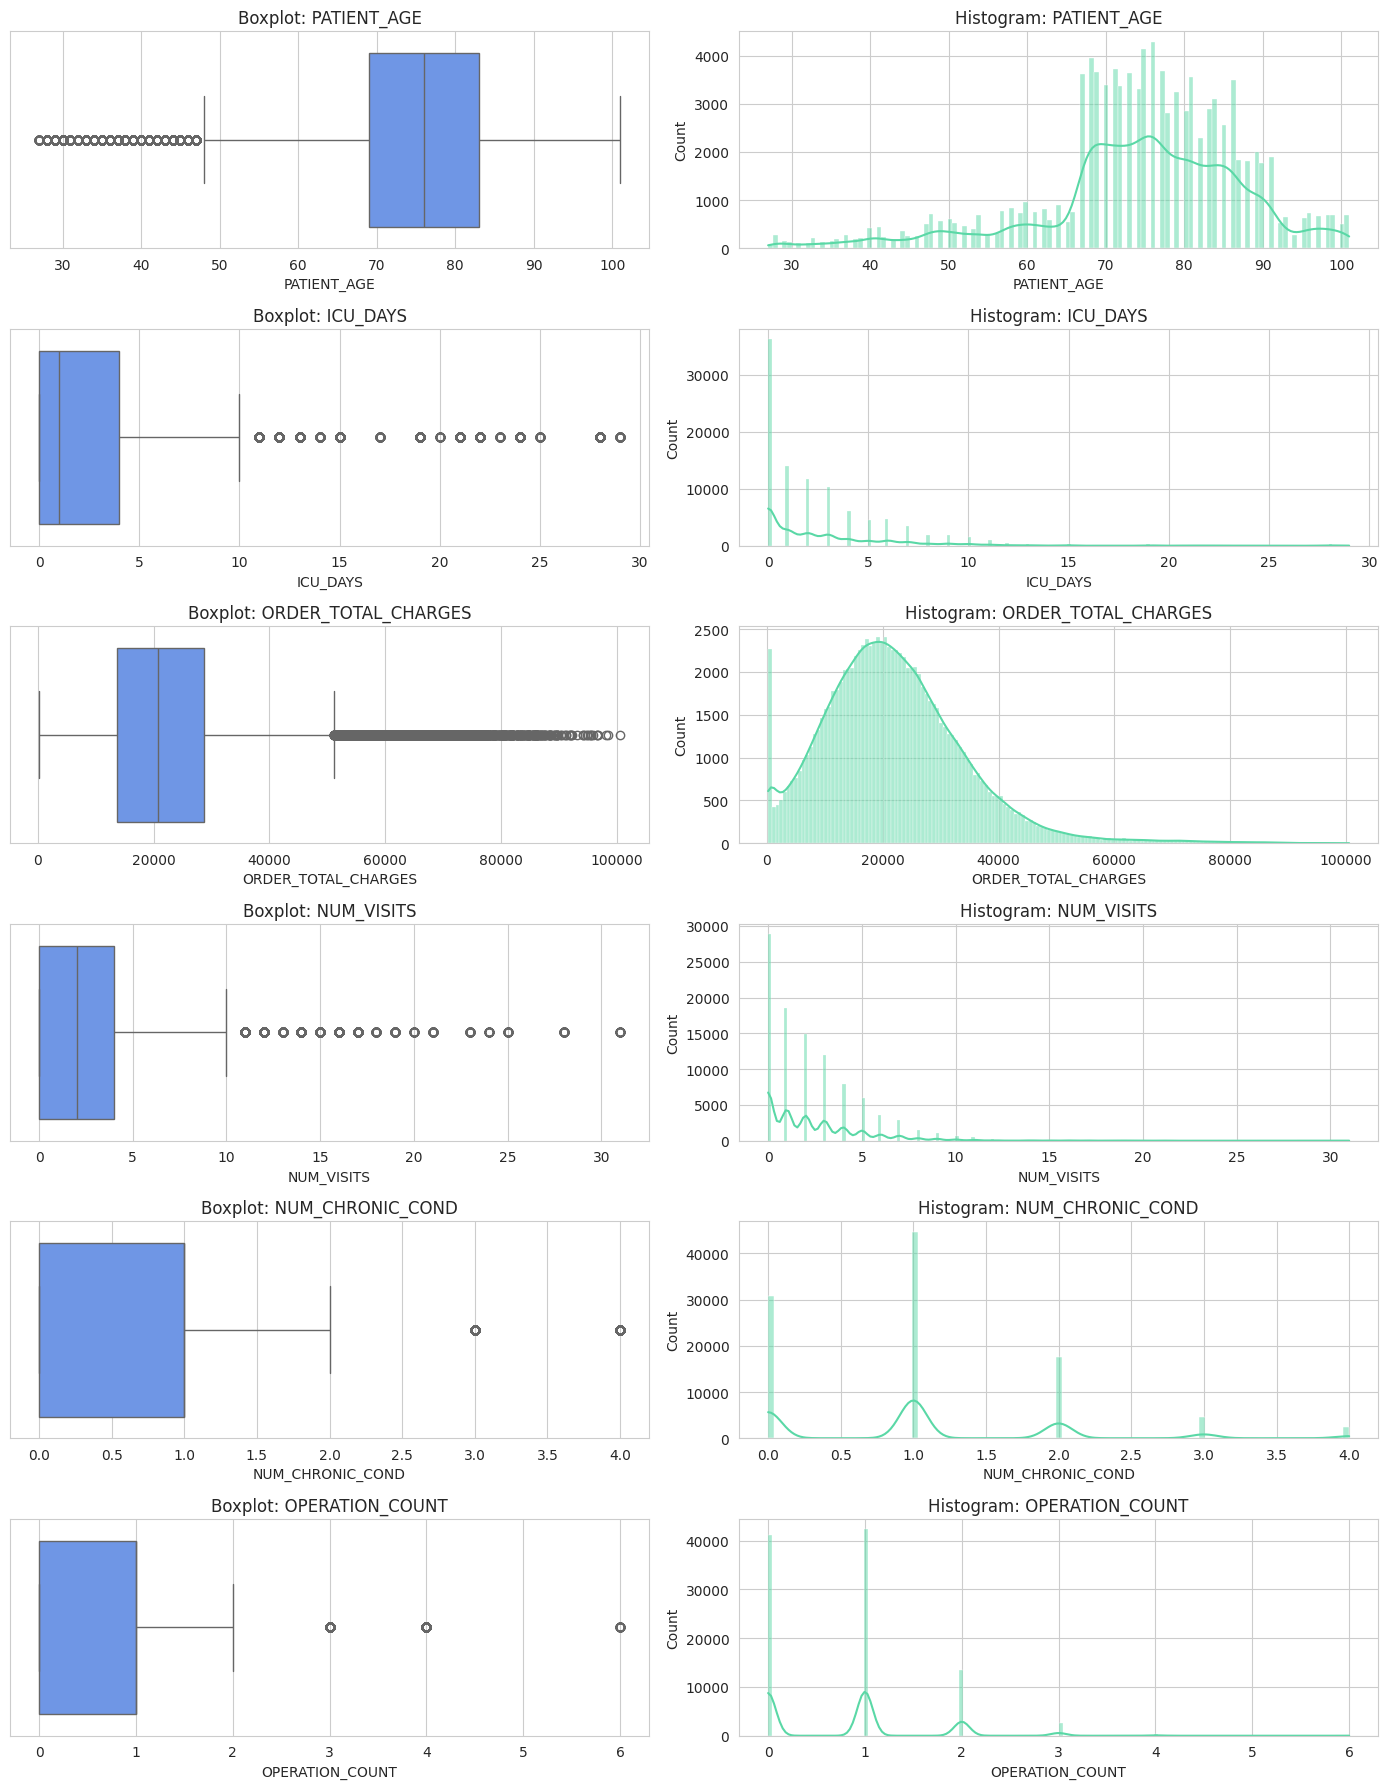

In [7]:
plot_cols = [c for c in candidate_numeric if c in train.columns and c != "ADMIT_LOS"]

fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, max(3, 3 * len(plot_cols))))
if len(plot_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(plot_cols):
    sns.boxplot(x=train[col], ax=axes[i, 0], color="#5B8FF9")
    axes[i, 0].set_title(f"Boxplot: {col}")
    sns.histplot(train[col], kde=True, ax=axes[i, 1], color="#5AD8A6")
    axes[i, 1].set_title(f"Histogram: {col}")

plt.tight_layout()
plt.show()


EDA

count    100000.000000
mean          5.760090
std           4.167187
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          51.000000
Name: ADMIT_LOS, dtype: float64
Skewness: 3.2627765391636796


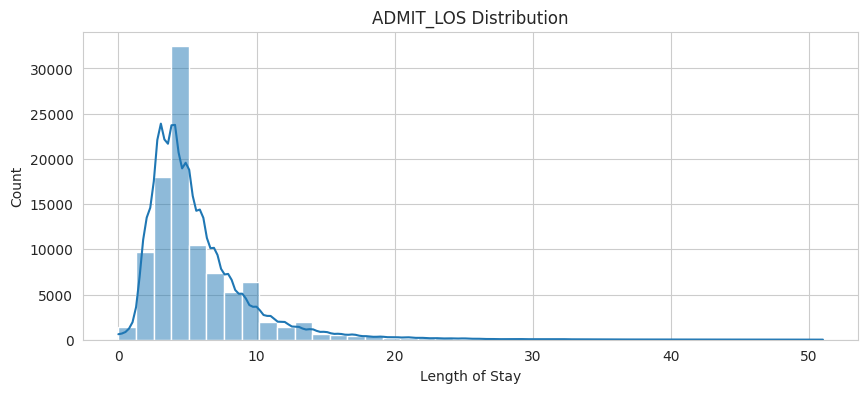

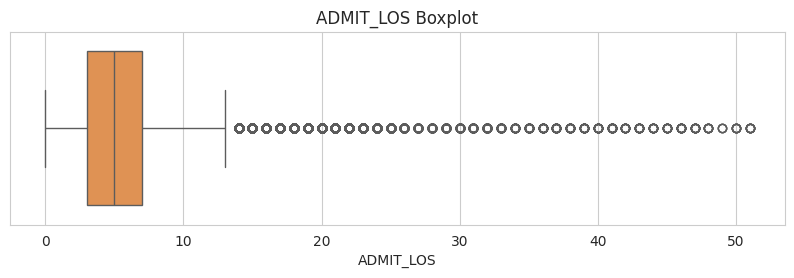

In [8]:
target_col = "ADMIT_LOS"
assert target_col in train.columns, "Target column ADMIT_LOS not found in train.csv"

print(train[target_col].describe())
print("Skewness:", train[target_col].skew())

plt.figure(figsize=(10, 4))
sns.histplot(train[target_col], bins=40, kde=True)
plt.title("ADMIT_LOS Distribution")
plt.xlabel("Length of Stay")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 2.5))
sns.boxplot(x=train[target_col], color="#F6903D")
plt.title("ADMIT_LOS Boxplot")
plt.show()


In [9]:
numeric_cols = train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

display(train[numeric_cols].describe().T.head(20))


Numeric columns: 26
Categorical columns: 20


,count,mean,std,min,25%,50%,75%,max
ENCOUNTER_KEY,100000.0,3.000500e+08,2.886766e+04,3.000000e+08,3.000250e+08,3.000500e+08,3.000750e+08,3.001000e+08
PATIENT_NUMBER,100000.0,7.504021e+08,1.440319e+08,5.000006e+08,6.258022e+08,7.502621e+08,8.751069e+08,9.999949e+08
DOCTOR,100000.0,2.680491e+05,3.745635e+04,2.016200e+05,2.354150e+05,2.680580e+05,2.975010e+05,3.445810e+05
ICU_DAYS,100000.0,2.756300e+00,3.854618e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,2.900000e+01
NUM_CHRONIC_COND,100000.0,1.029470e+00,9.388559e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
DISCH_NURSE_ID,100000.0,1.667334e+05,1.586596e+05,1.001000e+03,1.300500e+04,1.456040e+05,3.268520e+05,8.272980e+05
ORDER_SET_USED,100000.0,8.038300e-01,3.971006e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ORDER_TOTAL_CHARGES,100000.0,2.196222e+04,1.217863e+04,2.000000e+02,1.369600e+04,2.077750e+04,2.867400e+04,1.005600e+05
ZIP,100000.0,3.397352e+04,5.255866e+03,2.215000e+04,3.316100e+04,3.344400e+04,3.345500e+04,7.821900e+04
X,100000.0,-8.108273e+01,2.433410e+00,-9.838098e+01,-8.063284e+01,-8.021742e+01,-8.014331e+01,-7.705166e+01


In [10]:
for col in [c for c in ["DEPARTMENT", "HOSPITAL", "REGION", "GENDER", "DISCHARGED_TO"] if c in train.columns]:
    print(f"\n{col}: {train[col].nunique(dropna=False)} unique values")
    display(train[col].value_counts(dropna=False).head(10))



DEPARTMENT: 10 unique values


DEPARTMENT
HEART            54567
GENERAL MED      20576
PULMONARY         7786
ONCOLOGY          7362
TRANSPLANT        6055
Hosp 39           2652
NEUROSCIENCES      452
GENERAL SURG       275
WOMENS             247
PSYCH               28
Name: count, dtype: int64


HOSPITAL: 39 unique values


HOSPITAL
Hosp 36    2735
Hosp 12    2721
Hosp 16    2714
Hosp 26    2709
Hosp 33    2707
Hosp 35    2687
Hosp 38    2674
Hosp 22    2665
Hosp 17    2665
Hosp 6     2662
Name: count, dtype: int64


REGION: 11 unique values


REGION
Region 11    16987
Region 8     15481
Region 3     12807
Region 9     10108
Region 6      7874
Region 5      7871
Region 1      7870
Region 2      7839
Region 4      5334
Region 7      5185
Name: count, dtype: int64


GENDER: 2 unique values


GENDER
F    56819
M    43181
Name: count, dtype: int64


DISCHARGED_TO: 11 unique values


DISCHARGED_TO
ROUTINE DSCHG, HOME      63099
HOME HEALTH AGENCY       17343
SKILLED NURSING FACIL    10955
OTHER DEATH               3474
HOSPICE (HOME)            1921
INTERMEDIATE CARE         1416
AGNST MEDICAL ADVICE       824
CHG TO LTAC                408
OTHER ACUTE HOSP           297
REHAB HOSPITAL             140
Name: count, dtype: int64

Preprocessing



In [11]:

# Feature Selection & Preparation

id_col = "ENCOUNTER_KEY" if "ENCOUNTER_KEY" in train.columns else None


feature_train = train.copy()
feature_test = test.copy()


drop_cols = [
    c for c in [
        "DISCHARGE_DATE",
    ]
    if c in feature_train.columns
]

feature_train.drop(columns=drop_cols, inplace=True, errors="ignore")
feature_test.drop(columns=drop_cols, inplace=True, errors="ignore")

print("Removed leakage-prone columns:", drop_cols)

# Date Feature Extraction

for df in [feature_train, feature_test]:

    if "ADMIT_DATE" in df.columns:

        df["ADMIT_DATE"] = pd.to_datetime(
            df["ADMIT_DATE"],
            errors="coerce"
        )

        df["ADMIT_MONTH"] = df["ADMIT_DATE"].dt.month
        df["ADMIT_DAYOFWEEK"] = df["ADMIT_DATE"].dt.dayofweek

        df.drop(columns="ADMIT_DATE", inplace=True)

# Remove Identifier Columns

identifier_columns = [
    c for c in [
        "ENCOUNTER_KEY",
        "PATIENT_NUMBER",
        "DOCTOR",
        "DISCH_NURSE_ID",
    ]
    if c in feature_train.columns
]

print("Removed identifier columns:", identifier_columns)

# Feature / Target Split

X = feature_train.drop(
    columns=[target_col] + identifier_columns,
    errors="ignore",
)

y = feature_train[target_col].copy()

X_test_full = feature_test.drop(
    columns=identifier_columns,
    errors="ignore",
)

# Ensure identical feature sets

common_cols = sorted(
    set(X.columns).intersection(X_test_full.columns)
)

X = X[common_cols]
X_test_full = X_test_full[common_cols]

# Final Summary

print("\nFeature matrix shape :", X.shape)
print("Test feature shape   :", X_test_full.shape)

print("\nTotal Features Used:", len(X.columns))

Removed leakage-prone columns: []
Removed identifier columns: ['ENCOUNTER_KEY', 'PATIENT_NUMBER', 'DOCTOR', 'DISCH_NURSE_ID']



Feature matrix shape : (100000, 41)
Test feature shape   : (15000, 41)

Total Features Used: 41


In [12]:
# 80/20 split for a simple and beginner-friendly validation setup
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)


X_train: (80000, 41)
X_val  : (20000, 41)
y_train: (80000,)
y_val  : (20000,)


In [13]:
# Split into numeric and categorical columns based on the training set
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(num_features))
print("Categorical features:", len(cat_features))

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_features),
    ],
    remainder="drop",
)


Numeric features: 21
Categorical features: 20


In [14]:
print("=" * 60)
print("Feature Leakage Check")
print("=" * 60)

print(f"ADMIT_LOS in X            : {'ADMIT_LOS' in X.columns}")
print(f"ADMIT_DATE in X          : {'ADMIT_DATE' in X.columns}")
print(f"DISCHARGE_DATE in X      : {'DISCHARGE_DATE' in X.columns}")
print(f"ENCOUNTER_KEY in X       : {'ENCOUNTER_KEY' in X.columns}")
print(f"PATIENT_NUMBER in X      : {'PATIENT_NUMBER' in X.columns}")

print("\nNumber of Features:", len(X.columns))

print("\nFeature List:")
for col in X.columns:
    print(col)

Feature Leakage Check
ADMIT_LOS in X            : False
ADMIT_DATE in X          : False
DISCHARGE_DATE in X      : False
ENCOUNTER_KEY in X       : False
PATIENT_NUMBER in X      : False

Number of Features: 41

Feature List:
ADMIT_MTH
CARE_TEAM_SIZE
CITY
COMORBIDITY_INDEX
COUNTY_NAME
DEPARTMENT
DIAGNOSIS_GROUP
DIAGNOSIS_ICD_CODE
DIAGNOSIS_LONG_DESC
DIAGNOSIS_SUBCAT_CODE
DIAGNOSIS_SUBCAT_DESC
DISCHARGED_TO
DRG_APR_CODE
DRG_APR_DESC
DRG_APR_SEVERITY
DX_CODE
DX_GROUP
GENDER
HOSPITAL
ICD9_TARGET
ICU_DAYS
MONITORING_HOURS
MS_DRG_CODE
MS_DRG_DESC
NUM_CHRONIC_COND
NUM_VISITS
OPERATION_COUNT
ORDER_SET_USED
ORDER_TOTAL_CHARGES
PATIENT_AGE
PROCEDURE_ICD_CODE
PROCEDURE_LONG_DESC
PROCEDURE_SUBCAT_CODE
PROCEDURE_SUBCAT_DESC
RACE_CD
REGION
STANDARD_ORDERS_USED
STATECODE
X
Y
ZIP


Selecting Model

In [15]:
def evaluate_regression_model(
    name,
    framework,
    model,
    X_train,
    y_train,
    X_val,
    y_val,
):

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model),
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    predictions = pipe.predict(X_val)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    mae = mean_absolute_error(y_val, predictions)
    r2 = r2_score(y_val, predictions)

    return {
        "Framework": framework,
        "Model": name,
        "Pipeline": pipe,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
    }

# Candidate Models


sas_models = {

    "Linear Regression":
        SASLinearRegression(),

    "Ridge":
        SASRidge(),

    "Lasso":
        SASLasso(),

    "ElasticNet":
        SASElasticNet(),

    "Decision Tree":
        SASDecisionTreeRegressor(),

    "Forest":
        SASForestRegressor(),

    "Gradient Boosting":
        SASGradientBoostingRegressor(),

    "XGB Boost":
        XGBRegressor(),


}


# Benchmark

results = []
fitted_pipelines = {}

print("=" * 70)
print("MODEL BENCHMARKING")
print("=" * 70)


# SAS Models

print("\nBenchmarking SAS Viya Models...\n")

for name, model in sas_models.items():

    try:

        output = evaluate_regression_model(
            name=name,
            framework="SAS Viya",
            model=model,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
        )

        results.append({
            k: v
            for k, v in output.items()
            if k != "Pipeline"
        })

        fitted_pipelines[
            f"SAS Viya - {name}"
        ] = output["Pipeline"]

        print(
            f"✅ {name:<20}"
            f" RMSE={output['RMSE']:.4f}"
            f" | MAE={output['MAE']:.4f}"
            f" | R²={output['R²']:.4f}"
        )

    except Exception as e:

        print(f"❌ {name}")
        print(f"   {e}")

# Results

results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

results_df.index += 1
results_df.index.name = "Rank"

results_df = results_df.round(4)

print("\n")
print("=" * 70)
print("MODEL PERFORMANCE (Ranked by RMSE)")
print("=" * 70)

display(results_df)


# Best Model

best_model_info = results_df.iloc[0]

print("\n🏆 Best Model Selected")
print("-" * 40)

print(f"Framework : {best_model_info['Framework']}")
print(f"Model      : {best_model_info['Model']}")
print(f"RMSE       : {best_model_info['RMSE']:.4f}")
print(f"MAE        : {best_model_info['MAE']:.4f}")
print(f"R²         : {best_model_info['R²']:.4f}")

MODEL BENCHMARKING

Benchmarking SAS Viya Models...

✅ Linear Regression    RMSE=2.4906 | MAE=1.6405 | R²=0.6380
✅ Ridge                RMSE=2.4907 | MAE=1.6392 | R²=0.6380
✅ Lasso                RMSE=2.5099 | MAE=1.6198 | R²=0.6324
✅ ElasticNet           RMSE=2.4890 | MAE=1.6358 | R²=0.6385
✅ Decision Tree        RMSE=2.3706 | MAE=1.5025 | R²=0.6720
✅ Forest               RMSE=2.6214 | MAE=1.6683 | R²=0.5990
✅ Gradient Boosting    RMSE=2.0865 | MAE=1.3712 | R²=0.7459
✅ XGB Boost            RMSE=2.0501 | MAE=1.3591 | R²=0.7547


MODEL PERFORMANCE (Ranked by RMSE)


,Framework,Model,RMSE,MAE,R²
Rank,,,,,
1,SAS Viya,XGB Boost,2.0501,1.3591,0.7547
2,SAS Viya,Gradient Boosting,2.0865,1.3712,0.7459
3,SAS Viya,Decision Tree,2.3706,1.5025,0.6720
4,SAS Viya,ElasticNet,2.4890,1.6358,0.6385
5,SAS Viya,Linear Regression,2.4906,1.6405,0.6380
6,SAS Viya,Ridge,2.4907,1.6392,0.6380
7,SAS Viya,Lasso,2.5099,1.6198,0.6324
8,SAS Viya,Forest,2.6214,1.6683,0.5990



🏆 Best Model Selected
----------------------------------------
Framework : SAS Viya
Model      : XGB Boost
RMSE       : 2.0501
MAE        : 1.3591
R²         : 0.7547


Final Model

In [16]:
# Final Model Selection & Submission

selected_model = "SAS Viya - Gradient Boosting"

best_pipeline = fitted_pipelines[selected_model]

print("=" * 60)
print("Final Model Selected")
print("=" * 60)
print(selected_model)

print("\nTraining the selected model using the full training dataset...")

best_pipeline.fit(X, y)

print("Generating predictions on the competition test set...")

predictions = best_pipeline.predict(X_test_full)

# Prevent impossible negative Length of Stay predictions
predictions = np.clip(predictions, 0, None)

# Create submission dataframe
submission = pd.DataFrame({
    "ENCOUNTER_KEY": test["ENCOUNTER_KEY"],
    "ADMIT_LOS": predictions
})


assert len(submission) == len(test), \
    "Submission row count does not match the test dataset."

assert len(submission) == 15000, \
    f"Expected 15000 prediction rows, got {len(submission)}."

assert list(submission.columns) == [
    "ENCOUNTER_KEY",
    "ADMIT_LOS"
], "Submission column names are incorrect."

assert submission["ADMIT_LOS"].notna().all(), \
    "Submission contains missing predictions."

assert submission["ENCOUNTER_KEY"].is_unique, \
    "Duplicate ENCOUNTER_KEY values detected."

# Save submission
submission.to_csv("submission.csv", index=False)

print("\n✅ submission.csv generated successfully!")
print(f"Rows      : {len(submission)}")
print(f"Columns   : {list(submission.columns)}")
print("Header    : Included")
print("Filename  : submission.csv")

display(submission.head())

Final Model Selected
SAS Viya - Gradient Boosting

Training the selected model using the full training dataset...


Generating predictions on the competition test set...

✅ submission.csv generated successfully!
Rows      : 15000
Columns   : ['ENCOUNTER_KEY', 'ADMIT_LOS']
Header    : Included
Filename  : submission.csv


,ENCOUNTER_KEY,ADMIT_LOS
0,300100000,8.682037
1,300100001,9.722282
2,300100002,9.473350
3,300100003,3.157369
4,300100004,3.782114


In [17]:
# results_df.to_csv("model_results.csv", index=False)